# ML-09 — Validation and Research Claim Audit

**Lane:** CTR opportunity scoring; same-snapshot contextual CTR estimation. Prepared with AI assistance, with executed evidence from the approved starter slice. This continues the actual Week-5 tree/forest and training-only Week-4 peer rule; it does not replace the capstone objective with the starter decline classifier.

**Audit decision:** does the forest earn replacement of the peer rule under client-disjoint evaluation, and what can this evidence support? The editorial objective remains independent precision@20, which has no labels in this slice.

Reproduce with Python 3.11: install `work/requirements-w05.txt`, then run `python work/scripts/run_w06_validation_audit.py` or Run All. Outputs are embedded; only aggregate metrics are exported. The starter directory is nested inside the outer GitHub repo, so the committed path is `flyrank-ml-internship-starter-main/work/notebooks/w06_validation_audit.ipynb`.

## 1. Two paper findings + my methodology questions

Source: [FlyRank, *The State of AI-Driven SEO in Numbers*, March 2026](https://github.com/flyrank-bih/flyrank-ml-internship-starter/blob/main/docs/flyrank-seo-research-march-2026.pdf), the local 36-page PDF. Its main portfolio has 341,701 items / 57 brands; the exploratory ML subset has about 61,790 active items. Neither is this 30,000-page starter slice. Pages 4 and 36 prioritize direct aggregates and disclose observational limitations; these questions extend that disclosed standard rather than grade the paper.

### Finding A: click capture by position tier (Finding #3, p. 8)

The paper reports pooled CTR of 0.423% in the top three positions and 0.050% in deep positions, approximately 88% lower. This is a measured portfolio association, explicitly presented as a portfolio benchmark.

**Methodology question:** Could you show the click/impression denominators, client contributions and query/device/brand mix within each tier, and a within-client or matched-stratum sensitivity analysis? Does a prospective snippet experiment support the suggested incremental-click action, or is that an action hypothesis drawn from a descriptive comparison?

**Why ask:** CTR is calculated from clicks and impressions, while average position summarizes the same observation window. A large client's mix could dominate a pooled contrast, and association across tiers does not measure the effect of changing a snippet or ranking. I would welcome client-level uncertainty and separate pre/post windows, or a controlled edit study, before a causal improvement claim. Until then: lower CTR was observed in lower-visibility portfolio tiers; use it as directional decision-support.

**Transfer to my work:** keep CTR in percentage points, fit pooled peer CTR from training clients only, report an equal-client error alongside exposure-weighted error, and do not call a modeled CTR gap recoverable clicks.

### Finding B: what predicts health (ML appendix, p. 27; target definition pp. 5, 36)

The forest assigns 43% importance to position, 32% to impressions and 15% to scroll depth. The paper explicitly warns that its health target already incorporates several inputs and that importance is descriptive rather than causal.

**Methodology question:** Could you publish the exact health-label construction and preprocessing, then compare performance after removing all target components and siblings against an independently observed outcome? Were the disclosed 80/20 holdouts client-disjoint, and were predictors measured before any future outcome being claimed?

**Why ask:** the health formula allocates points to impressions, position, CTR and scroll depth. A holdout can still reward reconstruction of that definition. Page 36 states an 80/20 split but does not establish client or time separation; I do not infer either leakage or honest grouping from that description alone. Feature importance can describe model reliance without ranking intervention value. A target-component ablation, grouped validation, a naive reference and an independent outcome would answer a stronger question.

**Transfer to my work:** never feed CTR or target counts into the CTR estimator; deliberately test a target-derived feature as a diagnostic, remove it, and report only measured honest-split error. My CTR surrogate also cannot validate editorial quality without independent judgments.

## 2. My model under an honest split (before / after)

### 2a. Re-run the actual Week-5 model

Week 5 **already used disjoint clients**; calling it a random split would misstate the work. The following three code cells reuse its loader, seed, eligibility (≥500 impressions, position 1–20), peer support (≥30 training pages / ≥3 clients), exact 16/6/6 client partitions, models and metrics. Pipelines and peer tables fit only on training rows. The original validation decision stays frozen; no settings are tuned in this audit.

Target `100 × clicks_90d / impressions_90d` is current-snapshot CTR in percent; errors are percentage points (pp). The tree is depth 3 / leaf 100. The forest is 200 trees / depth 6 / leaf 50, bootstrap and seed 42, weighted by normalized training impressions. Features are position, content type and days since update. The original validation-selected method was the peer rule.

In [1]:
from pathlib import Path
import hashlib
import json
import platform
import sys
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor, export_text
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

SEED, K = 42, 20
MIN_IMPRESSIONS, MIN_PEER_PAGES, MIN_PEER_CLIENTS = 500, 30, 3
POSITION_EDGES = [0, 3, 10, 20]
POSITION_LABELS = ["1-3", ">3-10", ">10-20"]
FEATURES = ["avg_position", "content_type", "days_since_last_update"]
GROUP_KEYS = ["content_id", "client_id"]
COUNTS = ["impressions_90d", "clicks_90d"]
relative_csv = Path("data/raw/content_refresh_anonymized.csv")
root = next((candidate for base in (Path.cwd(), *Path.cwd().parents)
             for candidate in (base, base / "flyrank-ml-internship-starter-main")
             if (candidate / relative_csv).is_file()), None)
if root is None:
    raise FileNotFoundError("Run inside a clone with the approved starter CSV.")
df = pd.read_csv(root / relative_csv, usecols=GROUP_KEYS + COUNTS + FEATURES)
assert df.shape == (30000, 7) and df["client_id"].nunique() == 32
assert df[GROUP_KEYS].notna().all().all() and df["content_id"].is_unique
assert df[COUNTS + FEATURES].notna().all().all()
assert df[COUNTS].ge(0).all().all() and df["impressions_90d"].gt(0).all()
assert df["clicks_90d"].le(df["impressions_90d"]).all()
assert df["days_since_last_update"].ge(0).all()
lane = df.loc[df["impressions_90d"].ge(MIN_IMPRESSIONS)
              & df["avg_position"].between(1, 20)].copy()
lane["source_row"] = lane.index  # stable tie-break / audit only, never a feature
lane["observed_ctr_pct"] = 100 * lane["clicks_90d"] / lane["impressions_90d"]
lane["position_band"] = pd.cut(lane["avg_position"], POSITION_EDGES,
                               labels=POSITION_LABELS)
assert len(lane) == 12009
versions = {"python": platform.python_version(), "pandas": pd.__version__,
            "numpy": np.__version__, "scikit_learn": sklearn.__version__}
print(f"Starter: {len(df):,} pages; lane: {len(lane):,} pages, {lane['client_id'].nunique()} clients.")
print(f"Excluded missing-position sentinel (0): {df['avg_position'].eq(0).sum():,} pages.")
print("Missing model inputs: 0; no imputation fitted or zero filling required.")
print("Seed:", SEED, "| Versions:", versions)

Starter: 30,000 pages; lane: 12,009 pages, 28 clients.
Excluded missing-position sentinel (0): 1,205 pages.
Missing model inputs: 0; no imputation fitted or zero filling required.
Seed: 42 | Versions: {'python': '3.11.15', 'pandas': '3.0.6', 'numpy': '2.4.6', 'scikit_learn': '1.9.1'}


In [2]:
outer = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
dev_idx, test_idx = next(outer.split(lane, groups=lane["client_id"]))
dev = lane.iloc[dev_idx].copy()
inner = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=SEED)
train_idx, val_idx = next(inner.split(dev, groups=dev["client_id"]))
train, validation, test = dev.iloc[train_idx].copy(), dev.iloc[val_idx].copy(), lane.iloc[test_idx].copy()
partitions = {"train": train, "validation": validation, "test": test}
group_sets = {name: set(part["client_id"]) for name, part in partitions.items()}
assert not (group_sets["train"] & group_sets["validation"])
assert not (group_sets["train"] & group_sets["test"])
assert not (group_sets["validation"] & group_sets["test"])
assert set.union(*group_sets.values()) == set(lane["client_id"])
assert set.union(*(set(part.index) for part in partitions.values())) == set(lane.index)
assert sum(map(len, partitions.values())) == len(lane)

peer_keys = ["position_band", "content_type"]
peer_table = train.groupby(peer_keys, observed=True).agg(
    peer_pages=("content_id", "size"), peer_clients=("client_id", "nunique"),
    peer_impressions=("impressions_90d", "sum"), peer_clicks=("clicks_90d", "sum")
)
peer_table["baseline_ctr_pct"] = 100 * peer_table["peer_clicks"] / peer_table["peer_impressions"]

def attach_baseline(part):
    result = part.join(peer_table, on=peer_keys, validate="many_to_one")
    supported = (result["peer_pages"].ge(MIN_PEER_PAGES)
                 & result["peer_clients"].ge(MIN_PEER_CLIENTS)
                 & result["peer_impressions"].gt(0))
    result["supported"] = supported
    result["baseline_ctr_pct"] = result["baseline_ctr_pct"].where(supported)
    return result

validation = attach_baseline(validation)
test = attach_baseline(test)
val_eval = validation.loc[validation["supported"]].copy()
test_eval = test.loc[test["supported"]].copy()
assert len(val_eval) >= K and len(test_eval) >= K
# Direct aggregation independently verifies that the baseline uses training outcomes only.
for (band, kind), row in peer_table.iterrows():
    peers = train.loc[train["position_band"].eq(band) & train["content_type"].eq(kind)]
    assert np.isclose(row["baseline_ctr_pct"],
                      100 * peers["clicks_90d"].sum() / peers["impressions_90d"].sum())
split_table = pd.DataFrame([
    {"partition": name, "pages": len(part), "clients": part["client_id"].nunique(),
     "evaluation_pages": None if name == "train" else int(part["supported"].sum()),
     "deferred_pages": None if name == "train" else int((~part["supported"]).sum())}
    for name, part in {"train": train, "validation": validation, "test": test}.items()
])
display(split_table)
display(pd.concat([
    part.groupby("content_type", observed=True)["supported"].agg(pages="size", supported="sum")
    .assign(partition=name).reset_index()
    for name, part in [("validation", validation), ("test", test)]
], ignore_index=True))
print("PASS: disjoint client groups, exhaustive row partition, training-only baseline.")

,partition,pages,clients,evaluation_pages,deferred_pages
0,train,6519,16,NaN,NaN
1,validation,4669,6,4626.0,43.0
2,test,821,6,760.0,61.0


,content_type,pages,supported,partition
0,feedly article,43,0,validation
1,keyword article,4626,4626,validation
2,feedly article,61,0,test
3,keyword article,760,760,test


PASS: disjoint client groups, exhaustive row partition, training-only baseline.


In [3]:
def make_pipeline(estimator):
    preprocess = ColumnTransformer([
        ("numeric", "passthrough", ["avg_position", "days_since_last_update"]),
        ("type", OneHotEncoder(handle_unknown="ignore", sparse_output=False), ["content_type"]),
    ])
    return Pipeline([("preprocess", preprocess), ("model", estimator)])

models = {
    "shallow tree": make_pipeline(DecisionTreeRegressor(
        max_depth=3, min_samples_leaf=100, random_state=SEED)),
    "random forest": make_pipeline(RandomForestRegressor(
        n_estimators=200, max_depth=6, min_samples_leaf=50,
        bootstrap=True, random_state=SEED, n_jobs=1)),
}
weights = train["impressions_90d"] / train["impressions_90d"].mean()
for model in models.values():
    model.fit(train[FEATURES], train["observed_ctr_pct"], model__sample_weight=weights)

BASELINE = "Week-4 peer rule (train-only)"
def metric_row(part, prediction, method):
    pred = np.asarray(prediction, dtype=float)
    target = part["observed_ctr_pct"].to_numpy()
    assert pred.shape == target.shape and np.isfinite(pred).all()
    assert ((pred >= 0) & (pred <= 100)).all()
    errors = pred - target
    client_mae = pd.Series(np.abs(errors), index=part.index).groupby(part["client_id"]).mean()
    return {"method": method, "pages": len(part), "clients": part["client_id"].nunique(),
            "weighted_MAE_pp": float(np.average(np.abs(errors), weights=part["impressions_90d"])),
            "page_MAE_pp": float(np.abs(errors).mean()),
            "page_RMSE_pp": float(np.sqrt(np.mean(errors**2))),
            "equal_client_MAE_pp": float(client_mae.mean())}

val_predictions = {BASELINE: val_eval["baseline_ctr_pct"].to_numpy()}
val_predictions.update({name: model.predict(val_eval[FEATURES]) for name, model in models.items()})
validation_table = pd.DataFrame([metric_row(val_eval, pred, name)
                                for name, pred in val_predictions.items()])
# Baseline wins ties; no test outcome is used in selection.
selected = min(val_predictions, key=lambda name: float(validation_table.loc[
    validation_table["method"].eq(name), "weighted_MAE_pp"].iloc[0]))
challenger = min(models, key=lambda name: float(validation_table.loc[
    validation_table["method"].eq(name), "weighted_MAE_pp"].iloc[0]))
display(validation_table.round(6))
print("Frozen validation-selected method:", selected)
print("Best learned challenger for interpretation:", challenger)

# Final evaluation occurs only after selection. All methods use identical held-out rows.
test_predictions = {BASELINE: test_eval["baseline_ctr_pct"].to_numpy()}
test_predictions.update({name: model.predict(test_eval[FEATURES]) for name, model in models.items()})
test_table = pd.DataFrame([metric_row(test_eval, pred, name)
                          for name, pred in test_predictions.items()])
pooled_test_ctr = 100 * test_eval["clicks_90d"].sum() / test_eval["impressions_90d"].sum()
zero_click_rate = float(test_eval["clicks_90d"].eq(0).mean())
test_table["observed_pooled_CTR_pct"] = pooled_test_ctr
test_table["zero_click_page_rate"] = zero_click_rate
test_table["editorial_precision_at_20"] = "unavailable"
test_table["editorial_base_rate"] = "unavailable"
display(test_table.round(6))

,method,pages,clients,weighted_MAE_pp,page_MAE_pp,page_RMSE_pp,equal_client_MAE_pp
0,Week-4 peer rule (train-only),4626,6,0.227870,0.232535,0.291951,0.657352
1,shallow tree,4626,6,0.260186,0.264635,0.327670,0.649081
2,random forest,4626,6,0.257381,0.263246,0.327989,0.643586


Frozen validation-selected method: Week-4 peer rule (train-only)
Best learned challenger for interpretation: random forest


,method,pages,clients,weighted_MAE_pp,page_MAE_pp,page_RMSE_pp,equal_client_MAE_pp,observed_pooled_CTR_pct,zero_click_page_rate,editorial_precision_at_20,editorial_base_rate
0,Week-4 peer rule (train-only),760,6,0.383436,0.333139,0.542089,0.409930,0.597654,0.117105,unavailable,unavailable
1,shallow tree,760,6,0.388038,0.332450,0.549483,0.420579,0.597654,0.117105,unavailable,unavailable
2,random forest,760,6,0.385521,0.328947,0.547857,0.411985,0.597654,0.117105,unavailable,unavailable


In [4]:
previous = json.loads((root / "work/outputs/w05_model_metrics.json").read_text())
assert hashlib.sha256((root / relative_csv).read_bytes()).hexdigest() == previous["data_sha256"]
assert selected == previous["selected_on_validation"] == BASELINE
for row in previous["test_metrics"]:
    actual = test_table.loc[test_table["method"].eq(row["method"])].iloc[0]
    for key in ["weighted_MAE_pp", "page_MAE_pp", "page_RMSE_pp", "equal_client_MAE_pp"]:
        assert np.isclose(actual[key], row[key], atol=1e-8, rtol=0), key
print("PASS: actual Week-5 results reproduced within 1e-8 pp; settings and selection unchanged.")

PASS: actual Week-5 results reproduced within 1e-8 pp; settings and selection unchanged.


### 2b. Improvement: single client holdout → five-fold client-disjoint coverage

**Before:** one fixed client holdout leaves only six test clients and 760 peer-supported pages. **After:** grouped out-of-fold (OOF) predictions assess every eligible page once against a model trained on other clients; support still comes from each fold's training data. This improves coverage of the validation evidence, not necessarily predictive accuracy. Because the model/settings were chosen in earlier work involving these clients, this is a robustness audit, not a fresh independent final test or nested model-selection estimate.

For the assignment's random-versus-honest contrast, also run shuffled row KFold with the same five folds, seed and fixed forest. This random split is an **audit counterfactual**, never the original Week-5 design. Repeat clients may cross its train/test boundary even though identifiers are excluded from inputs. It asks about interpolation within observed portfolios, whereas GroupKFold asks about unseen clients.

Every preprocessing step, peer table and naive constant (training pooled CTR) is fitted within a fold. Evaluate forest, peer rule and naive constant on the **same intersection of peer-supported OOF rows across both split protocols**. Print deferred counts and pool composition. All metrics are held-out, never training errors. The group folds have unequal row sizes because portfolios differ; their error spread is descriptive, not a confidence interval. No seed search or tuning follows the result.

In [5]:
from sklearn.model_selection import KFold, GroupKFold

def forest_pipeline(extra_numeric=None):
    numeric = ["avg_position", "days_since_last_update"] + (extra_numeric or [])
    pre = ColumnTransformer([
        ("numeric", "passthrough", numeric),
        ("type", OneHotEncoder(handle_unknown="ignore", sparse_output=False), ["content_type"]),
    ])
    return Pipeline([("preprocess", pre), ("model", RandomForestRegressor(
        n_estimators=200, max_depth=6, min_samples_leaf=50,
        bootstrap=True, random_state=SEED, n_jobs=1))])

def crossfit(splitter, grouped):
    result = pd.DataFrame(index=lane.index,
                          columns=["forest", "peer", "constant", "supported", "fold"])
    fold_rows, visited = [], set()
    splits = splitter.split(lane, groups=lane["client_id"]) if grouped else splitter.split(lane)
    for fold, (tr_idx, te_idx) in enumerate(splits, 1):
        tr, te = lane.iloc[tr_idx].copy(), lane.iloc[te_idx].copy()
        assert not set(tr.index) & set(te.index)
        assert not visited & set(te.index)
        visited.update(te.index)
        overlap = len(set(tr["client_id"]) & set(te["client_id"]))
        if grouped:
            assert overlap == 0
        peers = tr.groupby(peer_keys, observed=True).agg(
            pages=("content_id", "size"), clients=("client_id", "nunique"),
            imp=("impressions_90d", "sum"), clicks=("clicks_90d", "sum"))
        peers["peer"] = 100 * peers["clicks"] / peers["imp"]
        scored = te.join(peers, on=peer_keys, validate="many_to_one")
        supported = scored["pages"].ge(30) & scored["clients"].ge(3)
        model = forest_pipeline()
        model.fit(tr[FEATURES], tr["observed_ctr_pct"],
                  model__sample_weight=tr["impressions_90d"] / tr["impressions_90d"].mean())
        result.loc[te.index, "forest"] = model.predict(te[FEATURES])
        result.loc[te.index, "peer"] = scored["peer"].where(supported)
        result.loc[te.index, "constant"] = 100 * tr["clicks_90d"].sum() / tr["impressions_90d"].sum()
        result.loc[te.index, "supported"] = supported
        result.loc[te.index, "fold"] = fold
        fold_rows.append({"fold": fold, "train_pages": len(tr), "heldout_pages": len(te),
                          "heldout_clients": te["client_id"].nunique(),
                          "overlap_clients": overlap, "supported_pages": int(supported.sum())})
    assert visited == set(lane.index)
    for col in ["forest", "peer", "constant"]:
        result[col] = pd.to_numeric(result[col])
    result["supported"] = result["supported"].astype(bool)
    result["fold"] = result["fold"].astype(int)
    assert np.isfinite(result[["forest", "constant"]]).all().all()
    return result, pd.DataFrame(fold_rows)

random_oof, random_folds = crossfit(KFold(5, shuffle=True, random_state=SEED), False)
group_oof, group_folds = crossfit(GroupKFold(5, shuffle=True, random_state=SEED), True)
common_mask = random_oof["supported"] & group_oof["supported"]
common = lane.loc[common_mask].copy()
assert common_mask.sum() > 0
assert random_folds["overlap_clients"].gt(0).all()
assert group_folds["overlap_clients"].eq(0).all()
print("Random row folds:"); display(random_folds)
print("Honest client folds:"); display(group_folds)
coverage = pd.DataFrame([
    {"protocol": name, "supported_pages": int(oof["supported"].sum()),
     "deferred_pages": int((~oof["supported"]).sum())}
    for name, oof in [("random", random_oof), ("grouped", group_oof)]])
display(coverage)
print(f"Paired common OOF pool: {len(common):,} pages / {common['client_id'].nunique()} clients.")
print("Common pool content-type counts:"); display(common["content_type"].value_counts().to_frame("pages"))

comparison_rows = []
for protocol, oof in [("random row OOF (counterfactual)", random_oof), ("grouped client OOF (honest)", group_oof)]:
    for col, name in [("constant", "naive training pooled CTR"), ("peer", "training-only peer rule"), ("forest", "frozen Week-5 forest")]:
        row = metric_row(common, oof.loc[common.index, col].to_numpy(), name)
        row.update(protocol=protocol,
                   observed_pooled_CTR_pct=100*common["clicks_90d"].sum()/common["impressions_90d"].sum(),
                   zero_click_page_rate=float(common["clicks_90d"].eq(0).mean()),
                   editorial_base_rate="unavailable")
        comparison_rows.append(row)
comparison = pd.DataFrame(comparison_rows)
display(comparison.round(6))
fold_rows_metrics = []
for fold in range(1,6):
    part=common.loc[group_oof.loc[common.index,"fold"].eq(fold)]
    row=dict(fold=fold, **metric_row(part,group_oof.loc[part.index,"forest"].to_numpy(),"forest"))
    row.update(naive_weighted_MAE_pp=metric_row(part,group_oof.loc[part.index,"constant"].to_numpy(),"naive")["weighted_MAE_pp"],
               peer_weighted_MAE_pp=metric_row(part,group_oof.loc[part.index,"peer"].to_numpy(),"peer")["weighted_MAE_pp"],
               observed_pooled_CTR_pct=100*part["clicks_90d"].sum()/part["impressions_90d"].sum(),
               zero_click_page_rate=float(part["clicks_90d"].eq(0).mean()),editorial_base_rate="unavailable")
    fold_rows_metrics.append(row)
fold_metrics=pd.DataFrame(fold_rows_metrics)
print("Honest fold errors (different clients and row counts; naive and peer references alongside):")
display(fold_metrics.round(6))
before_after=pd.DataFrame([
    {"stage":"Before: original Week-5 single client test", "pages":len(test_eval),
     "clients":test_eval["client_id"].nunique(),"forest_weighted_MAE_pp":float(test_table.loc[test_table["method"].eq("random forest"),"weighted_MAE_pp"].iloc[0]),
     "peer_weighted_MAE_pp":float(test_table.loc[test_table["method"].eq(BASELINE),"weighted_MAE_pp"].iloc[0])},
    {"stage":"After: broader grouped OOF audit", "pages":len(common),"clients":common["client_id"].nunique(),
     "forest_weighted_MAE_pp":float(comparison.loc[comparison["protocol"].str.startswith("grouped") & comparison["method"].eq("frozen Week-5 forest"),"weighted_MAE_pp"].iloc[0]),
     "peer_weighted_MAE_pp":float(comparison.loc[comparison["protocol"].str.startswith("grouped") & comparison["method"].eq("training-only peer rule"),"weighted_MAE_pp"].iloc[0])}])
print("Before/after validation coverage: different client mixes, not a paired accuracy gain.")
display(before_after.round(6))
random_mae = comparison.loc[comparison["protocol"].str.startswith("random") & comparison["method"].eq("frozen Week-5 forest"), "weighted_MAE_pp"].iloc[0]
group_mae = comparison.loc[comparison["protocol"].str.startswith("grouped") & comparison["method"].eq("frozen Week-5 forest"), "weighted_MAE_pp"].iloc[0]
display(Markdown(f"**Measured random → honest contrast:** forest weighted MAE {random_mae:.6f} → {group_mae:.6f} pp; signed difference {group_mae-random_mae:+.6f} pp on identical pages. A positive gap is consistent with harder transfer across clients, but does not isolate memorization: portfolio mix, training row counts and feature relationships also change. Grouping removes direct client overlap; it does not establish temporal validity or causation."))

Random row folds:


,fold,train_pages,heldout_pages,heldout_clients,overlap_clients,supported_pages
0,1,9607,2402,27,27,2395
1,2,9607,2402,26,26,2379
2,3,9607,2402,26,26,2379
3,4,9607,2402,26,26,2379
4,5,9608,2401,26,26,2386


Honest client folds:


,fold,train_pages,heldout_pages,heldout_clients,overlap_clients,supported_pages
0,1,11188,821,6,0,793
1,2,11734,275,6,0,207
2,3,5854,6155,6,0,6154
3,4,10531,1478,5,0,1477
4,5,8729,3280,5,0,3280


,protocol,supported_pages,deferred_pages
0,random,11918,91
1,grouped,11911,98


...

Honest fold errors (different clients and row counts; naive and peer references alongside):


,fold,method,pages,clients,weighted_MAE_pp,page_MAE_pp,page_RMSE_pp,equal_client_MAE_pp,naive_weighted_MAE_pp,peer_weighted_MAE_pp,observed_pooled_CTR_pct,zero_click_page_rate,editorial_base_rate
0,1,forest,793,6,0.389920,0.320370,0.551892,0.432829,0.389215,0.391119,0.596125,0.123581,unavailable
1,2,forest,207,6,0.291156,0.293247,0.508284,0.684069,0.272913,0.295551,0.258475,0.135266,unavailable
2,3,forest,6154,6,0.250821,0.266490,0.324040,0.330968,0.232186,0.241850,0.316522,0.099610,unavailable
3,4,forest,1477,5,0.221125,0.258374,0.338653,0.300044,0.219387,0.218035,0.282405,0.090047,unavailable
4,5,forest,3280,5,0.281146,0.262248,0.404430,0.250313,0.272301,0.278631,0.429809,0.091463,unavailable


Before/after validation coverage: different client mixes, not a paired accuracy gain.


,stage,pages,clients,forest_weighted_MAE_pp,peer_weighted_MAE_pp
0,Before: original Week-5 single client test,760,6,0.385521,0.383436
1,After: broader grouped OOF audit,11911,28,0.264557,0.258531


**Measured random → honest contrast:** forest weighted MAE 0.220839 → 0.264557 pp; signed difference +0.043719 pp on identical pages. A positive gap is consistent with harder transfer across clients, but does not isolate memorization: portfolio mix, training row counts and feature relationships also change. Grouping removes direct client overlap; it does not establish temporal validity or causation.

## 3. Leakage audit + real failure examples

### Prediction timeline and scope

`[same trailing-90-day window: position + clicks + impressions] → snapshot review; content type + days-since-update measured at snapshot → contextual benchmark / review queue`

The target and average-position input **share the window**. They are available at a snapshot review, but are not strictly earlier than a future label. Therefore this model is only a descriptive current-snapshot estimator for unseen clients. The starter has no reliable export timestamp or separate forward outcomes; sorting by content age would not create time validation. A future claim would require daily data, features ending at time t, a strictly later label window, client-aware split choices and an appropriate gap for overlapping windows. This audit makes no future-performance claim.

The allowlist is deliberately narrow. Counts are used for target, eligibility, exposure weighting and reporting; they never enter X. The final review score may use observed CTR intentionally, but that cannot serve as an independent label of editorial value. The table audits **every raw column**; unspecified columns fail rather than silently entering training. Systematic keyword/length missingness is a reason to defer adding them, not fill everything with zero.

In [6]:
audit_groups = [
    (FEATURES, "allowlisted input", "position is concurrent; type/freshness at snapshot, not pre-outcome evidence"),
    (GROUP_KEYS, "group/join only", "IDs never model inputs"),
    (COUNTS, "target / eligibility / weights only", "direct CTR ingredients; excluded from X"),
    (["ctr"], "exclude: target-derived", "rounded version of the regression target"),
    (["trend_direction", "trend_pct"], "exclude: other-label sources", "define decline, including overlapping trend windows"),
    (["impressions_last_30d", "clicks_last_30d", "sessions_last_30d", "impressions_prev_30d", "clicks_prev_30d", "sessions_prev_30d"], "exclude: overlapping traffic windows", "snapshot target overlaps both windows; no future cutoff"),
    (["pageviews_90d", "sessions_90d", "users_90d", "engaged_sessions_90d", "ai_sessions_90d", "scroll_events_90d", "days_with_impressions", "days_with_sessions", "engagement_rate", "scroll_rate", "ai_traffic_pct"], "exclude: concurrent traffic / ratios", "can encode current outcomes or coverage; not prior-window predictors"),
    (["provider_used", "model_used"], "exclude: provenance", "not a predictor per data contract"),
    (["search_volume", "competition", "competition_level", "cpc", "main_intent", "word_count", "char_count", "content_age_days"], "exclude: not in frozen model", "unvalidated extra metadata / systematic missingness; no post-audit tuning"),
    (["age_tier", "age_tier_order", "freshness_tier", "word_count_tier", "char_count_tier", "impression_tier", "position_tier"], "exclude: derived buckets", "redundant or target-sibling context; not in allowlist"),
]
raw_columns = pd.read_csv(root / relative_csv, nrows=0).columns.tolist()
audit_rows = [{"column": col, "role": role, "reason": reason}
              for cols, role, reason in audit_groups for col in cols]
audit_table = pd.DataFrame(audit_rows)
assert len(audit_table) == len(raw_columns) == 44
assert audit_table["column"].is_unique and set(audit_table["column"]) == set(raw_columns)
assert audit_table.loc[audit_table["role"].eq("allowlisted input"), "column"].tolist() == FEATURES
display(audit_table)
print("Derived prep fields (decline label, log traffic, has-clicks/AI, opportunity flag), health scores and product flags are also excluded: loader reads only the seven audited columns.")
assert set(df.columns) == set(GROUP_KEYS + COUNTS + FEATURES)

,column,role,reason
0,avg_position,allowlisted input,position is concurrent; type/freshness at snap...
1,content_type,allowlisted input,position is concurrent; type/freshness at snap...
2,days_since_last_update,allowlisted input,position is concurrent; type/freshness at snap...
3,content_id,group/join only,IDs never model inputs
4,client_id,group/join only,IDs never model inputs
5,impressions_90d,target / eligibility / weights only,direct CTR ingredients; excluded from X
6,clicks_90d,target / eligibility / weights only,direct CTR ingredients; excluded from X
7,ctr,exclude: target-derived,rounded version of the regression target
8,trend_direction,exclude: other-label sources,"define decline, including overlapping trend wi..."
9,trend_pct,exclude: other-label sources,"define decline, including overlapping trend wi..."


Derived prep fields (decline label, log traffic, has-clicks/AI, opportunity flag), health scores and product flags are also excluded: loader reads only the seven audited columns.


### Deliberately add a leaky target sibling, then remove it

On the original fixed client test pool, add the CSV's rounded `ctr` to the **same forest** as a forbidden diagnostic. Read only that one additional column locally. Its provenance, not just a suspicious metric, makes it inadmissible. Compare with the clean frozen forest, then discard it. An exact target-echo linear-regression probe should also give essentially zero held-out error, confirming that the metric harness can detect answer access. Neither probe is a candidate model, and neither changes feature selection or deployment.

In [7]:
from sklearn.linear_model import LinearRegression
rounded_ctr = pd.read_csv(root / relative_csv, usecols=["ctr"])["ctr"]
assert np.allclose(rounded_ctr, (100*df["clicks_90d"]/df["impressions_90d"]).round(2), atol=0.01)
probe_train, probe_test = train[FEATURES].copy(), test_eval[FEATURES].copy()
probe_train["forbidden_ctr"] = rounded_ctr.loc[train.index]
probe_test["forbidden_ctr"] = rounded_ctr.loc[test_eval.index]
leaky = forest_pipeline(["forbidden_ctr"])
leaky.fit(probe_train, train["observed_ctr_pct"],
          model__sample_weight=train["impressions_90d"]/train["impressions_90d"].mean())
# Clip only numerical roundoff at physical CTR bounds for the exact-echo probe.
echo = LinearRegression().fit(train[["observed_ctr_pct"]], train["observed_ctr_pct"])
probe_rows = [metric_row(test_eval, test_predictions["random forest"], "clean frozen forest"),
              metric_row(test_eval, leaky.predict(probe_test), "FORBIDDEN rounded CTR input"),
              metric_row(test_eval, np.clip(echo.predict(test_eval[["observed_ctr_pct"]]), 0, 100), "FORBIDDEN exact target echo")]
probe_table = pd.DataFrame(probe_rows)
probe_table["observed_pooled_CTR_pct"] = pooled_test_ctr
probe_table["zero_click_page_rate"] = zero_click_rate
probe_table["editorial_base_rate"] = "unavailable"
display(probe_table.round(6))
assert probe_table.iloc[2]["weighted_MAE_pp"] < 1e-10
assert probe_table.iloc[1]["weighted_MAE_pp"] < probe_table.iloc[0]["weighted_MAE_pp"]
probe_reduction = 1-probe_table.iloc[1]["weighted_MAE_pp"]/probe_table.iloc[0]["weighted_MAE_pp"]
print(f"Measured target-sibling error reduction: {probe_reduction:.1%}; target-derived input is excluded regardless of improvement size.")
del leaky, echo, probe_train, probe_test, rounded_ctr
assert FEATURES == ["avg_position", "content_type", "days_since_last_update"]
print("PASS: leak probes discarded; clean forest and peer rule remain the evaluated decision-support methods.")

,method,pages,clients,weighted_MAE_pp,page_MAE_pp,page_RMSE_pp,equal_client_MAE_pp,observed_pooled_CTR_pct,zero_click_page_rate,editorial_base_rate
0,clean frozen forest,760,6,0.385521,0.328947,0.547857,0.411985,0.597654,0.117105,unavailable
1,FORBIDDEN rounded CTR input,760,6,0.054965,0.037173,0.230656,0.094115,0.597654,0.117105,unavailable
2,FORBIDDEN exact target echo,760,6,0.000000,0.000000,0.000000,0.000000,0.597654,0.117105,unavailable


Measured target-sibling error reduction: 85.7%; target-derived input is excluded regardless of improvement size.
PASS: leak probes discarded; clean forest and peer rule remain the evaluated decision-support methods.


### Real held-out failure examples and feature reliance

Use the honest grouped OOF forest on the common pool. Pick the largest overestimate, largest underestimate, largest remaining impression-weighted residual and the highest-ranked positive review-gap case. These are deterministic real rows; use local case numbers, rounded CTR and banded context, with no IDs or raw dataset dump. The review-gap case has no independent editorial truth and is not automatically a wrong editorial recommendation. Hypotheses about query/device/intent mix need investigation.

**Case 1:** Overestimation: a context benchmark misses weak measured click capture. Check query/device mix and snippet intent before editing.

**Case 2:** Underestimation: strong observed capture is missed; brand or SERP mix may differ from training portfolios. Do not generalize this residual into a refresh effect.

**Case 3:** Exposure-weighted failure: volume amplifies this error. Validate counts and matched-peer context before accepting a large review gap.

**Case 4:** High-priority review case: the score is a click-equivalent discrepancy, not recoverable clicks or proof of a useful edit. Ask an independent editor for a blinded judgment.

,case,type,position_band,exposure_band,observed_CTR_pct,estimated_CTR_pct,signed_error_pp
0,1,keyword article,>3-10,500-3k,0.000,0.699,0.699
1,2,keyword article,>3-10,500-3k,5.422,0.277,-5.145
2,3,keyword article,>3-10,>30k,1.945,0.602,-1.343
3,4,keyword article,1-3,>30k,0.154,0.540,0.386


,method,pages,clients,weighted_MAE_pp,page_MAE_pp,page_RMSE_pp,equal_client_MAE_pp,small_sample_caution,observed_pooled_CTR_pct,zero_click_page_rate,editorial_base_rate
0,1-3,463,15,0.338238,0.327267,0.399895,0.367035,False,0.492151,0.118790,unavailable
1,>3-10,7034,28,0.261422,0.276378,0.384025,0.387119,False,0.348747,0.065254,unavailable
2,>10-20,4414,25,0.252502,0.249424,0.348371,0.362469,False,0.351386,0.149071,unavailable


,feature,increase_weighted_MAE_pp,shuffle_SD_pp
0,avg_position,0.011956,0.002477
1,content_type,0.000000,0.000000
2,days_since_last_update,-0.004100,0.002967


Importance is diagnostic reliance, not a causal effect; shuffle SD is not a confidence interval. Zero type importance on the original all-keyword test pool cannot establish irrelevance. Negative freshness importance demonstrates no useful reliance on that pool.


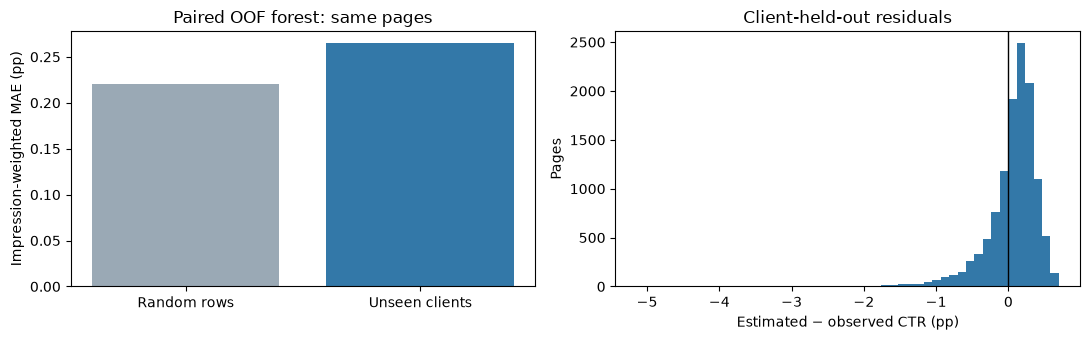

In [8]:
diagnostics = common.copy()
diagnostics["prediction"] = group_oof.loc[common.index, "forest"]
diagnostics["signed_error_pp"] = diagnostics["prediction"]-diagnostics["observed_ctr_pct"]
diagnostics["abs_error_pp"] = diagnostics["signed_error_pp"].abs()
diagnostics["exposure_band"] = pd.cut(diagnostics["impressions_90d"], [499,3000,30000,np.inf], labels=["500-3k", ">3k-30k", ">30k"])
diagnostics["review_proxy"] = diagnostics["impressions_90d"] * diagnostics["signed_error_pp"].clip(lower=0)/100
case_indices = [diagnostics["signed_error_pp"].idxmax(), diagnostics["signed_error_pp"].idxmin()]
remaining = diagnostics.drop(index=case_indices)
case_indices.append((remaining["abs_error_pp"]*remaining["impressions_90d"]).idxmax())
case_indices.append(diagnostics.drop(index=case_indices)["review_proxy"].idxmax())
assert len(set(case_indices)) == 4
notes = [
    "Overestimation: a context benchmark misses weak measured click capture. Check query/device mix and snippet intent before editing.",
    "Underestimation: strong observed capture is missed; brand or SERP mix may differ from training portfolios. Do not generalize this residual into a refresh effect.",
    "Exposure-weighted failure: volume amplifies this error. Validate counts and matched-peer context before accepting a large review gap.",
    "High-priority review case: the score is a click-equivalent discrepancy, not recoverable clicks or proof of a useful edit. Ask an independent editor for a blinded judgment."
]
case_rows = []
for number, (idx, note) in enumerate(zip(case_indices, notes),1):
    r = diagnostics.loc[idx]
    case_rows.append({"case": number, "type": r["content_type"], "position_band": str(r["position_band"]),
                      "exposure_band": str(r["exposure_band"]), "observed_CTR_pct": round(r["observed_ctr_pct"],3),
                      "estimated_CTR_pct": round(r["prediction"],3), "signed_error_pp": round(r["signed_error_pp"],3)})
    display(Markdown(f"**Case {number}:** {note}"))
display(pd.DataFrame(case_rows))
slice_rows=[]
for band, part in diagnostics.groupby("position_band", observed=True):
    row=metric_row(part, part["prediction"], str(band))
    row.update(small_sample_caution=len(part)<30,
               observed_pooled_CTR_pct=100*part["clicks_90d"].sum()/part["impressions_90d"].sum(),
               zero_click_page_rate=float(part["clicks_90d"].eq(0).mean()), editorial_base_rate="unavailable")
    slice_rows.append(row)
slices=pd.DataFrame(slice_rows)
display(slices.round(6))
# Fixed Week-5 model importance: held-out original pool, no refit after inspection.
importance=permutation_importance(models["random forest"],test_eval[FEATURES],test_eval["observed_ctr_pct"],
    scoring="neg_mean_absolute_error",sample_weight=test_eval["impressions_90d"],n_repeats=10,random_state=SEED,n_jobs=1)
importance_table=pd.DataFrame({"feature":FEATURES,"increase_weighted_MAE_pp":importance.importances_mean,
                                "shuffle_SD_pp":importance.importances_std})
display(importance_table.round(6))
print("Importance is diagnostic reliance, not a causal effect; shuffle SD is not a confidence interval. Zero type importance on the original all-keyword test pool cannot establish irrelevance. Negative freshness importance demonstrates no useful reliance on that pool.")
fig,axes=plt.subplots(1,2,figsize=(11,3.5))
plot=comparison.loc[comparison["method"].eq("frozen Week-5 forest")]
axes[0].bar(["Random rows", "Unseen clients"],plot["weighted_MAE_pp"],color=["#9aa9b5","#3378a8"])
axes[0].set(title="Paired OOF forest: same pages",ylabel="Impression-weighted MAE (pp)")
axes[1].hist(diagnostics["signed_error_pp"],bins=50,color="#3378a8")
axes[1].axvline(0,color="black",linewidth=1)
axes[1].set(title="Client-held-out residuals",xlabel="Estimated − observed CTR (pp)",ylabel="Pages")
fig.tight_layout(); plt.show(); plt.close(fig)

## 4. Claim rewrite

The actual Week-5 conclusion was already cautious: retain the transparent peer rule; no earned replacement on the primary validation metric. I preserve that decision and narrow the evidence further. The following bold sentences are **counterfactual overclaims to audit**, not quotations from Week 5 or claims I endorse.

| Tempting overclaim | Public-safe rewrite |
|---|---|
| “The forest generalizes across clients.” | We measured CTR estimation error on disjoint-client snapshot partitions and grouped OOF folds in this starter slice; this supports a limited transfer diagnostic, not performance for every client or future period. |
| “A higher modeled CTR means these edits will recover clicks.” | The measured gap is a directional decision-support review proxy. Independent blinded editorial judgments and prospective outcomes are required to estimate review precision or any causal click lift. |
| “Freshness/position is an SEO lever because the model uses it.” | We observed model reliance under input shuffling; concurrent visibility, client mix and editorial selection can confound the association. Importance does not measure intervention value. |
| “The random-to-grouped gap proves client memorization.” | The gap is consistent with more difficult cross-client transfer. Group composition, training size and distribution shift also change; this comparison does not isolate memorization. |
| “The low error with CTR validates the model.” | The deliberately added feature encodes the answer. Its diagnostic score shows why target-derived inputs must be removed; only the clean feature model supports the reported surrogate evidence. |

Uncertainty is at the client level, not 12,000 independent pages. No statistical significance, confidence interval, time validation, causal effect or editorial precision@20 is claimed. The repeated OOF folds use previously inspected data; collect new clients and later windows for an independent final evaluation.

In [9]:
group_metrics = comparison.loc[comparison["protocol"].str.startswith("grouped")].set_index("method")
forest_error=group_metrics.loc["frozen Week-5 forest","weighted_MAE_pp"]
peer_error=group_metrics.loc["training-only peer rule","weighted_MAE_pp"]
constant_error=group_metrics.loc["naive training pooled CTR","weighted_MAE_pp"]
relation="lower" if forest_error<peer_error else "higher"
top=diagnostics.loc[diagnostics["review_proxy"].gt(0)].sort_values(
    ["review_proxy","impressions_90d","source_row"],ascending=[False,False,True],kind="stable").head(K)
queue_share=float(top["client_id"].value_counts().max()/len(top))
client_exposure=common.groupby("client_id")["impressions_90d"].sum()
display(Markdown(
    f"**Observed audit result:** on {len(common):,} common OOF pages from {common['client_id'].nunique()} clients, "
    f"the frozen forest measured {forest_error:.6f} pp weighted MAE, {relation} than the training-only peer rule "
    f"({peer_error:.6f} pp); the naive training pooled-CTR reference measured {constant_error:.6f} pp. "
    f"Random-row forest error was {random_mae:.6f} pp. "
    "The original six-client holdout and this broader robustness diagnostic estimate different evaluation mixes; neither is a temporal test. "
    "The original validation-selected peer-rule decision remains unchanged. "
    "The naive pooled-CTR reference is better than both contextual methods on grouped weighted MAE, "
    "so this audit also finds no evidence that added context earns complexity on that metric; "
    "retaining the original rule does not establish that it is the strongest predictor or a validated editorial policy.\n\n"
    f"**Decision-support limitation:** the largest common-pool client supplies {client_exposure.max()/client_exposure.sum():.1%} "
    f"of impressions. The grouped-OOF top-{K} proxy queue spans {top['client_id'].nunique()} clients, with "
    f"{queue_share:.1%} of slots in its largest client. Independent editorial precision@20 and its base rate are unavailable. "
    "Use the result to prioritize measurement and blinded review, without promising recovered clicks or refresh uplift.\n\n"
    "**Next evidence:** use daily data with feature windows strictly before labels, audit tracking coverage, reserve new clients or later periods, "
    "collect independent editor labels and random-pool controls, and compare prospective edit outcomes before stronger claims."))

**Observed audit result:** on 11,911 common OOF pages from 28 clients, the frozen forest measured 0.264557 pp weighted MAE, higher than the training-only peer rule (0.258531 pp); the naive training pooled-CTR reference measured 0.250899 pp. Random-row forest error was 0.220839 pp. The original six-client holdout and this broader robustness diagnostic estimate different evaluation mixes; neither is a temporal test. The original validation-selected peer-rule decision remains unchanged. The naive pooled-CTR reference is better than both contextual methods on grouped weighted MAE, so this audit also finds no evidence that added context earns complexity on that metric; retaining the original rule does not establish that it is the strongest predictor or a validated editorial policy.

**Decision-support limitation:** the largest common-pool client supplies 46.3% of impressions. The grouped-OOF top-20 proxy queue spans 5 clients, with 60.0% of slots in its largest client. Independent editorial precision@20 and its base rate are unavailable. Use the result to prioritize measurement and blinded review, without promising recovered clicks or refresh uplift.

**Next evidence:** use daily data with feature windows strictly before labels, audit tracking coverage, reserve new clients or later periods, collect independent editor labels and random-pool controls, and compare prospective edit outcomes before stronger claims.

## 5. Self-check

- [x] Two identified paper findings, page references, constructive methodology questions and transfer to my model.
- [x] Actual Week-5 model reproduced; random split labeled as counterfactual; grouped OOF improvement and paired before/after metrics reported.
- [x] Every raw column audited; preprocessing and benchmarks fit within training folds; client overlap asserted absent in honest folds.
- [x] Concurrent windows disclosed; no artificial time split or future prediction claim.
- [x] Deliberate target-sibling and target-echo probes verified, then removed; fixed clean allowlist restored.
- [x] Naive regression reference, pooled target context, zero-click frequency and unavailable editorial base rate shown.
- [x] Four real anonymized failure/review cases, slices, coverage and concentration; no identifiers, client names or private queries printed.
- [x] Claim rewrites use observed, measured, directional and decision-support; uncertainties and absent outcomes stated.
- [x] All code cells execute top to bottom; final assertions write a small aggregate receipt.

Execution does not prove GitHub publication or portal submission. Those are verified externally after committing this executed notebook. No raw datasets or row-level queues are generated or committed by this audit.

In [10]:
assert not set(FEATURES)&set(GROUP_KEYS+COUNTS+["ctr","trend_pct","trend_direction","is_declining_label"])
assert group_folds["overlap_clients"].eq(0).all()
assert comparison["pages"].nunique()==comparison["clients"].nunique()==1
assert np.isfinite(comparison[["weighted_MAE_pp","page_MAE_pp","page_RMSE_pp","equal_client_MAE_pp"]]).all().all()
assert comparison["editorial_base_rate"].eq("unavailable").all()
assert selected==BASELINE
assert len(case_rows)==4

def records(table):
    return json.loads(table.to_json(orient="records",double_precision=10))
receipt={
    "assignment":"ML-09", "scope":"same-snapshot starter-slice CTR surrogate; not future or causal",
    "seed":SEED,"versions":versions,"features":FEATURES,
    "data_sha256":hashlib.sha256((root/relative_csv).read_bytes()).hexdigest(),
    "paper_findings":[{"finding":"#3 position-tier pooled CTR","page":8},
                      {"finding":"ML appendix health-score importance","page":27}],
    "week5_reproduced":True,"original_selection":selected,"original_test_metrics":records(test_table),
    "oof_coverage":records(coverage),"common_oof_pages":len(common),"common_oof_clients":common["client_id"].nunique(),
    "random_fold_structure":records(random_folds),"grouped_fold_structure":records(group_folds),
    "before_after_coverage":records(before_after),"oof_comparison":records(comparison),"honest_fold_metrics":records(fold_metrics),
    "random_to_grouped_weighted_mae_gap_pp":float(group_mae-random_mae),
    "leak_probe_metrics":records(probe_table),"leak_probes_removed":True,"audited_raw_columns":len(audit_table),
    "grouped_error_slices":records(slices),"original_holdout_permutation_importance":records(importance_table),
    "anonymized_cases_shown":4,"grouped_top20_clients":int(top["client_id"].nunique()),
    "grouped_top20_largest_client_slot_share":queue_share,
    "independent_editorial_labels":0,"editorial_precision_at_20":None,
    "limitations":["Concurrent feature/target window", "No temporal validation", "No causal effect",
                   "No independent editorial labels", "OOF audit revisits previously inspected clients",
                   "Unequal group fold sizes; client mix and exposure concentration", "Unsupported cohorts deferred"],
    "verification":"All assertions passed; clean frozen models, training-only peers, disjoint client OOF and matched evaluation pool"
}
out=root/"work/outputs/w06_validation_audit_metrics.json"
out.write_text(json.dumps(receipt,indent=2,allow_nan=False)+"\n")
print("PASS: all audit assertions; saved aggregate work/outputs/w06_validation_audit_metrics.json.")

PASS: all audit assertions; saved aggregate work/outputs/w06_validation_audit_metrics.json.
